<a href="https://colab.research.google.com/github/SampreethNaik06/Coding-Practice/blob/main/Matplotllib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# basics for matplotlib

In [ ]:
# Activity 1
# line Plot

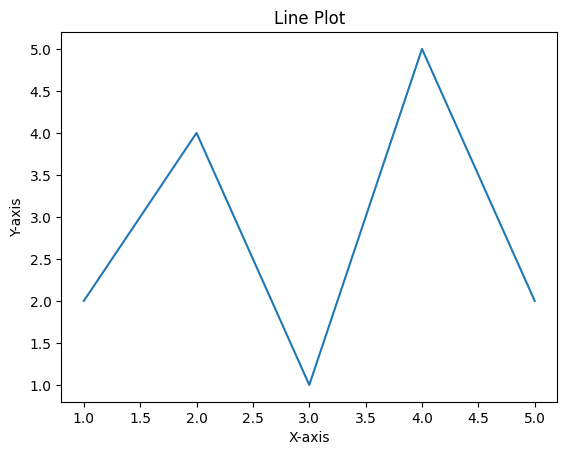

In [3]:
import matplotlib.pyplot as plt

# Sample data
x = [1, 2, 3, 4, 5]
y = [2, 4, 1, 5, 2]

plt.plot(x, y)
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Line Plot')
plt.show()

In [11]:
# Activity 2
import pandas as pd
from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)
df = iris.frame
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


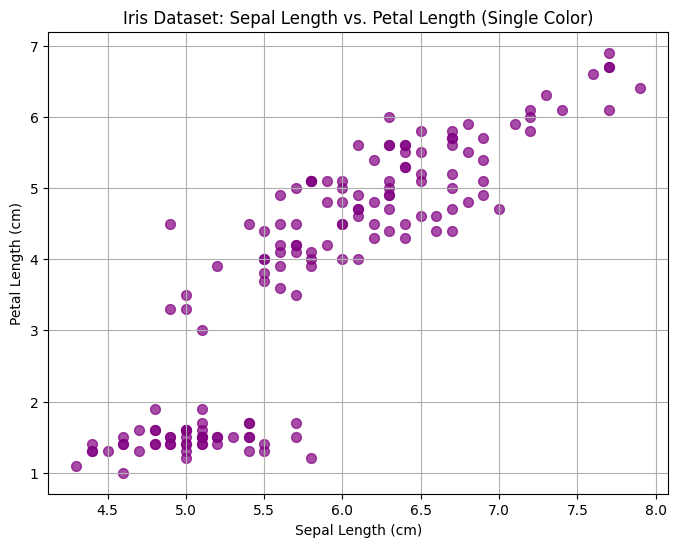

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(
    df['sepal length (cm)'],
    df['petal length (cm)'],
    color='purple',  # Using a single color, e.g., purple
    s=50,            # Marker size
    alpha=0.7        # Transparency
)

plt.title('Iris Dataset: Sepal Length vs. Petal Length (Single Color)')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.grid(True)
plt.show()

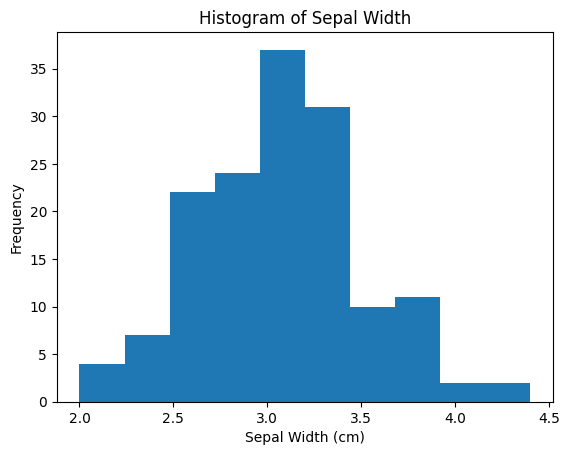

In [16]:
# Activity 3

plt.hist(df['sepal width (cm)'], bins=10)
plt.title('Histogram of Sepal Width')
plt.xlabel('Sepal Width (cm)')
plt.ylabel('Frequency')
plt.show()

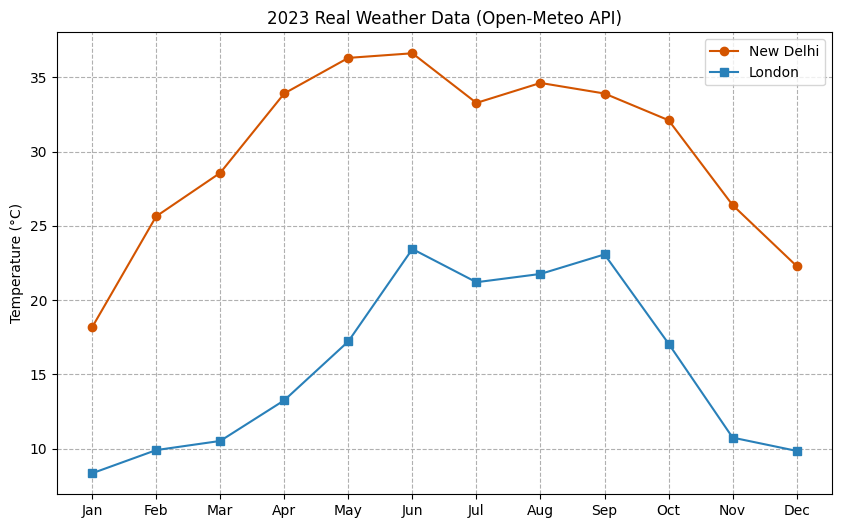

In [30]:

url = "https://archive-api.open-meteo.com/v1/archive"

def fetch_city_data(lat, lon):
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": "2023-01-01",
        "end_date": "2023-12-31",
        "daily": "temperature_2m_max",
        "timezone": "auto"
    }
    res = requests.get(url, params=params).json()
    df = pd.DataFrame(res['daily'])
    df['time'] = pd.to_datetime(df['time'])
    # Resample to monthly average
    return df.resample('ME', on='time')['temperature_2m_max'].mean().values

# Coordinates: New Delhi & London
delhi_temps = fetch_city_data(28.6139, 77.2090)
london_temps = fetch_city_data(51.5074, -0.1278)

# Build DataFrame
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df = pd.DataFrame({'Month': months, 'New Delhi': delhi_temps, 'London': london_temps})

# Plot
plt.figure(figsize=(10, 6))
plt.plot(df['Month'], df['New Delhi'], marker='o', label='New Delhi', color='#d35400')
plt.plot(df['Month'], df['London'], marker='s', label='London', color='#2980b9')
plt.title('2023 Real Weather Data (Open-Meteo API)')
plt.ylabel('Temperature (°C)')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()